In [ ]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('asiacup.csv')
df.head()

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  119 non-null    int64  
 1   Player      119 non-null    object 
 2   Span        119 non-null    object 
 3   Mat         119 non-null    int64  
 4   Inns        119 non-null    int64  
 5   NO          119 non-null    int64  
 6   Runs        119 non-null    int64  
 7   HS          119 non-null    object 
 8   Ave         119 non-null    float64
 9   BF          119 non-null    int64  
 10  SR          119 non-null    float64
 11  100         119 non-null    int64  
 12  50          119 non-null    int64  
 13  0           119 non-null    int64  
 14  4s          119 non-null    object 
 15  6s          119 non-null    object 
dtypes: float64(2), int64(9), object(5)
memory usage: 15.0+ KB


In [6]:
df = pd.read_csv('asiacup.csv')

In [7]:
df.isnull().sum()

Unnamed: 0    0
Player        0
Span          4
Mat           0
Inns          3
NO            1
Runs          4
HS            2
Ave           3
BF            1
SR            1
100           0
50            0
0             1
4s            1
6s            2
dtype: int64

In [25]:
# Drop index column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
# Handle '*' in High Scores
df['HS'] = df['HS'].astype(str).str.replace('*', '', regex=False)
# Convert all stats to numbers
cols = ['Inns', 'Runs', 'Ave', 'SR', 'BF', 'Mat', '4s', '6s', 'HS', '100', '50', '0']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
# Fill NaN values
df.fillna(0, inplace=True) # Sab missing values ko 0 kar dena sab se safe hai cricket stats mein

print("Data Cleaned Successfully!")

Data Cleaned Successfully!


In [26]:
df.isnull().sum()

Player    0
Span      0
Mat       0
Inns      0
NO        0
Runs      0
HS        0
Ave       0
BF        0
SR        0
100       0
50        0
0         0
4s        0
6s        0
dtype: int64

C:\Users\Zeeshan\AppData\Local\Temp\ipykernel_5696\3474262024.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Runs', y='Player', data=top_10, palette='viridis')


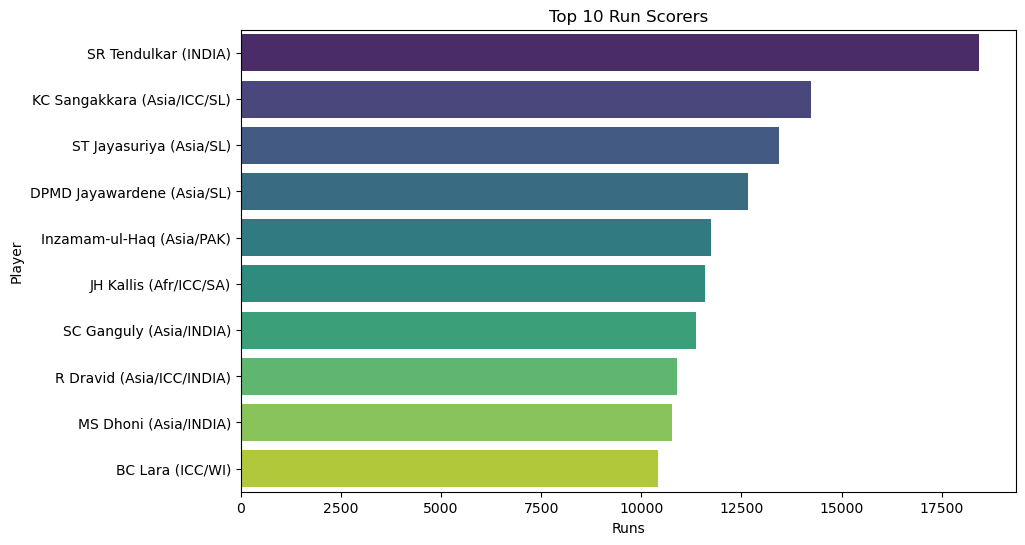

In [27]:
# top 10 scorers
top_10 = df.sort_values(by='Runs', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Runs', y='Player', data=top_10, palette='viridis')
plt.title('Top 10 Run Scorers')
plt.savefig('my_graph.png', dpi=300, bbox_inches='tight')
plt.show()

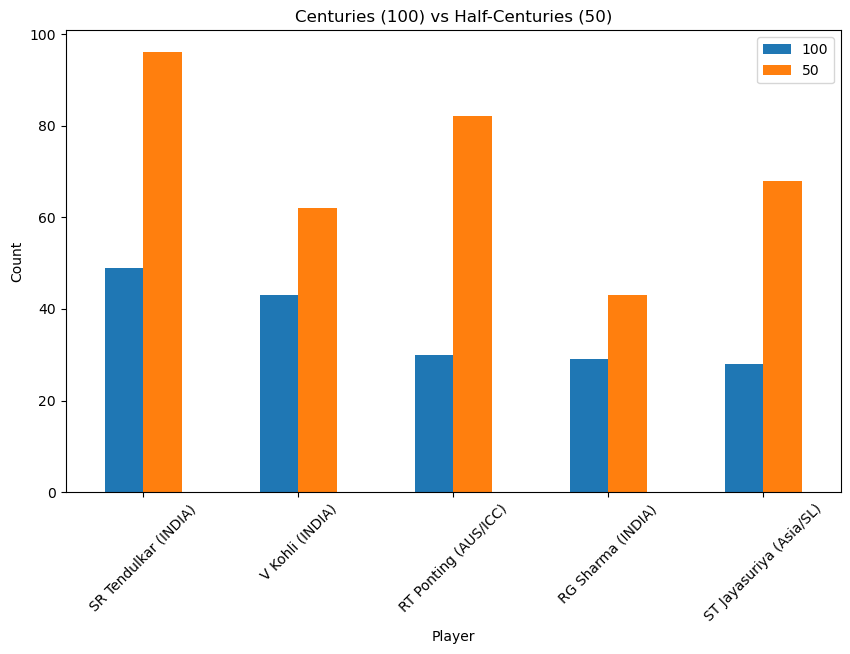

In [28]:
# Select top 5 players for clarity
top_5 = df.head(5)
top_5.set_index('Player')[['100', '50']].plot(kind='bar', figsize=(10, 6))
plt.title('Centuries (100) vs Half-Centuries (50)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('my_graph.png', dpi=300, bbox_inches='tight')
plt.show()

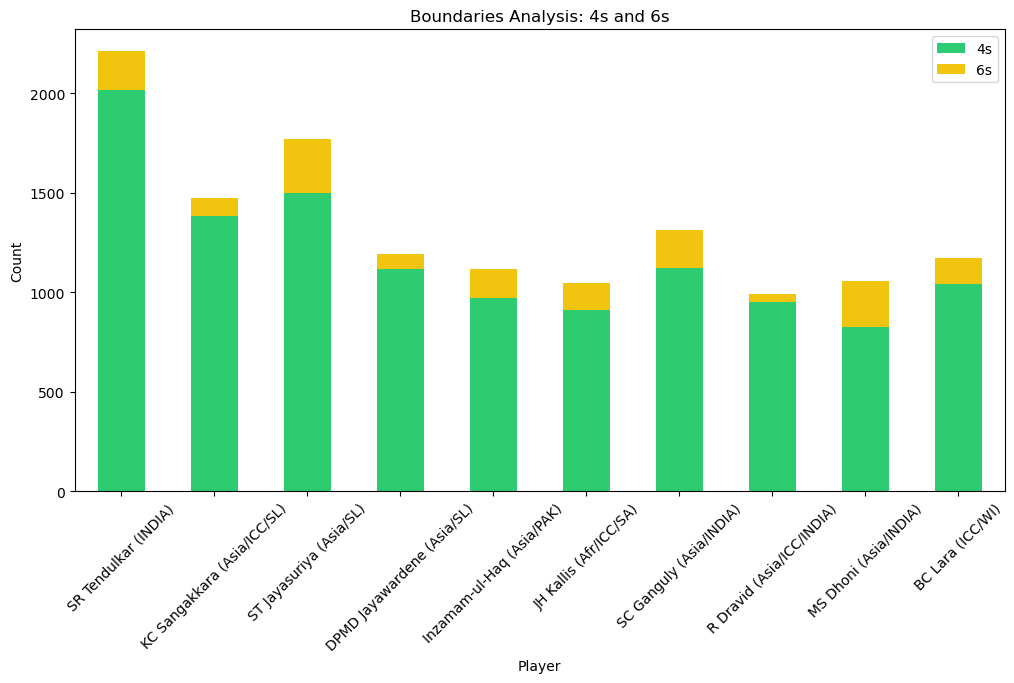

In [30]:
# chart for  Boundaries
top_10.set_index('Player')[['4s', '6s']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2ecc71', '#f1c40f'])
plt.title('Boundaries Analysis: 4s and 6s')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('my_graph.png', dpi=300, bbox_inches='tight')
plt.show()

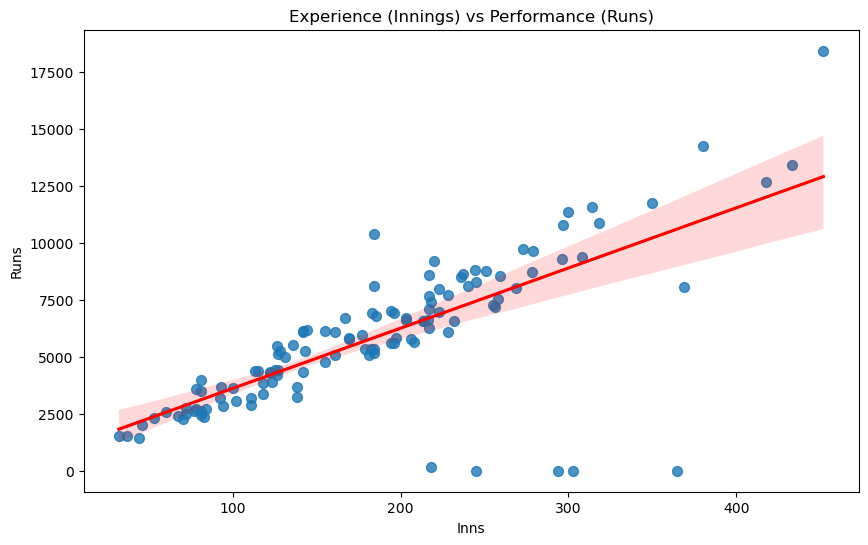

In [31]:
# Scatter Plot for Innings vs Runs
plt.figure(figsize=(10, 6))
sns.regplot(x='Inns', y='Runs', data=df, scatter_kws={'s':50}, line_kws={'color':'red'})
plt.title('Experience (Innings) vs Performance (Runs)')
plt.savefig('my_graph.png', dpi=300, bbox_inches='tight')
plt.show()